## Welcome to the **COMP40771 CI Lab 2** where we are going to cover the **Continuous Optimisation & Numerical Parameter Tuning**.
In this session, we focus on algorithms designed for continuous search spaces—domains where parameters are real-valued, often high-dimensional, and potentially non-linear. These problems typically lack accessible gradients, making traditional gradient-based methods less effective.
**Continuous Optimisation & Numerical Parameter Tuning**

Algorithms in this category excel when the search space is **continuous**, often high-dimensional, non-linear, and possibly without accessible gradients.

| Algorithm | Why It's Used Here | Typical Applications |
|----------|--------------------|----------------------|
| **Particle Swarm Optimisation (PSO)** | Efficient for smooth or noisy continuous landscapes; swarm intelligence stabilises search | Neural network tuning, PID tuning |
| **Evolution Strategies (ES)** | Self-adaptive mutation scales ideal for continuous domains | Robotics control, aerodynamic shape optimisation |
| **Differential Evolution (DE)** | Strong global search through difference-vector recombination | Hyperparameter optimisation, regression weight tuning |
| **Artificial Bee Colony (ABC)** | Food-source optimisation fits continuous search | Clustering, feature optimisation |
| **Genetic Algorithm (GA)** *(real-coded)* | Handles large continuous domains well | Engineering optimisation, model calibration |
| **Artificial Neural Networks (ANNs)** *(regression)* | Learn continuous mappings | Forecasting, physical model approximation |

**Common Theme:**  
These algorithms optimise **real-valued continuous parameters** and work well without gradients.

## Learning Outcomes (LOs)
By the end of this lab, you should be able to:

* Understand the principles behind continuous optimisation algorithms and why they are suitable for real-valued parameter tuning.
* Compare different algorithms (e.g., PSO, DE, ES) in terms of their mechanisms, strengths, and typical applications.
* Implement and apply at least one continuous optimisation algorithm to a practical problem.
* Evaluate performance using appropriate metrics and discuss trade-offs between exploration and exploitation in continuous domains.
* Relate algorithm choice to problem characteristics, such as dimensionality, smoothness, and presence of noise.
---
## Particle Swarm Optimisation
### Understanding PSO in the Context of Linear Regression
We use **Particle Swarm Optimisation (PSO)** to find the **optimal weights** for a linear regression model.  
Instead of relying on gradient descent (as in `LinearRegression` or `SGDRegressor` from scikit-learn),  
PSO searches the parameter space **stochastically** — by simulating a swarm of particles that cooperate to find the best solution.

The goal is to **find the optimal linear regression weight vector** `w = [w₁, w₂, ..., wₙ]`  
that minimises the **Mean Squared Error (MSE)** between the predicted and actual values:

$\text{MSE}(w) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y_i})^2$
where:
- $(y_i)$ is the true output for sample $i$,
- $( \hat{y_i} = X_i \cdot w )$ is the model’s prediction,
- $(X_i)$ is the feature vector for sample $i$,
- $(N)$ is the total number of samples.

In essence, PSO searches for the **weight vector `w`** that produces the lowest MSE.

### Particles
Each **particle** in the swarm represents a **candidate solution**, i.e. a possible set of regression weights:

$\text{particle}_j = [w_{j1}, w_{j2}, w_{j3}, ..., w_{jn}]$

- Every particle has a **position** (its current solution) and a **velocity** (its direction and speed of change).
- The position defines the current hypothesis (the current weight vector).
- The swarm collectively explores the search space of all possible weights.

### Fitness function
The **fitness** of each particle measures how good its current position (i.e. weight vector) is.  
In this experiment, fitness is defined as the **Mean Squared Error** between the model’s predictions and the true target values:

$\text{fitness}(w) = \text{mean\_squared\_error}(y, X @ w)$

- Lower fitness values correspond to **better** solutions.
- PSO seeks to **minimise** this value — the smaller the MSE, the better the regression fit.

### Search dynamics (particle movement)
Particles move through the weight space using three guiding forces:

1. **Inertia (w × velocity)**  
   - Keeps the particle moving in its current direction, maintaining momentum.  
   - Helps prevent premature convergence by encouraging exploration.

2. **Cognitive Component (c₁ × r₁ × (pbest - position))**  
   - Represents the particle’s **own experience**.  
   - Pulls the particle back toward its **personal best position** (where it achieved the lowest error so far).

3. **Social Component (c₂ × r₂ × (gbest - position))**  
   - Represents the **swarm’s shared intelligence**.  
   - Pulls the particle toward the **global best position** found by any particle in the swarm.

$v_{i}(t+1) = w \cdot v_{i}(t) + c_1 \cdot r_1 \cdot (pbest_i - x_i) + c_2 \cdot r_2 \cdot (gbest - x_i)$
$x_{i}(t+1) = x_{i}(t) + v_{i}(t+1)$

where:  
- $w$: the inertia weight  
- $c_1$ and $c_2$: the cognitive and social coefficients
- $r_1$ and $r_2$: the random factors (uniformly distributed between 0 and 1)
- $v_i$: the velocity of particle $i$  
- $x_i$: the current position (weights) of particle $i$  

## Understanding MSE and R² in model evaluation

### Mean Squared Error (MSE)

**Mean Squared Error (MSE)** measures how close the predicted values are to the actual target values.  
It calculates the **average of the squared differences** between predicted and true values:

$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y_i})^2$

- $y_i$: true value for sample *i*  
- $\hat{y_i}$: predicted value for sample *i*  
- $N$: number of data samples  

**Interpretation:**
- A **lower MSE** indicates better model performance (smaller prediction errors).  
- The squaring penalises large errors more heavily, which helps detect models that make occasional large mistakes.

**Units:**  
Because errors are squared, MSE has **squared units** of the target variable (e.g., if *y* is in metres, MSE is in m²).


### Coefficient of determination (R²)

**R² (R-squared)** measures how well the model explains the variability of the target data.  
It compares the model’s performance to a simple **baseline** that always predicts the mean of *y*:

$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$

where:
- $\text{SS}_{\text{res}} = \sum (y_i - \hat{y_i})^2$: residual sum of squares (model error)  
- $\text{SS}_{\text{tot}} = \sum (y_i - \bar{y})^2$: total sum of squares (data variance)

**Interpretation:**
- $R^2 = 1.0$: perfect fit (predictions match targets exactly)  
- $R^2 = 0.0$: model performs no better than predicting the mean  
- $R^2 < 0.0$: model performs **worse** than predicting the mean (poor generalisation)

**Relation to MSE:**
- MSE gives the **absolute magnitude** of prediction error.  
- R² gives the **relative performance** compared to a baseline — a normalised measure of how well the model captures variance in the data.

### Example interpretation

| Metric | Meaning | Example Outcome |
|---------|----------|----------------|
| **MSE = 25.4** | On average, the squared prediction error is 25.4 units² | Model errors are moderate in size |
| **R² = 0.87** | 87% of the target variance is explained by the model | Model fits the data well, small unexplained variance |

**In summary:**  
- **MSE** → measures *how far off* your predictions are.  
- **R²** → measures *how much of the data’s variability* your model explains.

### In summary
- Each particle explores different weight combinations (`w₁, w₂, w₃, …`) for the regression model.  
- Particles **share information** with one another — if one discovers a better set of weights, others tend to move toward it.  
- Over time, the swarm collectively converges on an optimal (or near-optimal) solution that minimises MSE.  
- Unlike gradient descent, PSO does **not** require derivatives, making it effective for non-differentiable or noisy loss functions.

### Key takeaway
PSO acts as a **collaborative, adaptive search** algorithm:  
- It balances **exploration** (trying new weight combinations) with **exploitation** (refining good solutions).  
- In this lab, it achieves the same objective as regression training — **finding the best-fit model parameters** —  
  but through **biologically inspired collective behaviour** rather than deterministic optimisation.

Iteration 000 | Best MSE: 6665.8799
Iteration 010 | Best MSE: 1356.7438
Iteration 020 | Best MSE: 411.9174
Iteration 030 | Best MSE: 139.7231
Iteration 040 | Best MSE: 100.3857
Iteration 050 | Best MSE: 100.3198
Iteration 060 | Best MSE: 100.3125
Iteration 070 | Best MSE: 100.3121
Iteration 080 | Best MSE: 100.3121
Iteration 090 | Best MSE: 100.3121
Iteration 099 | Best MSE: 100.3121


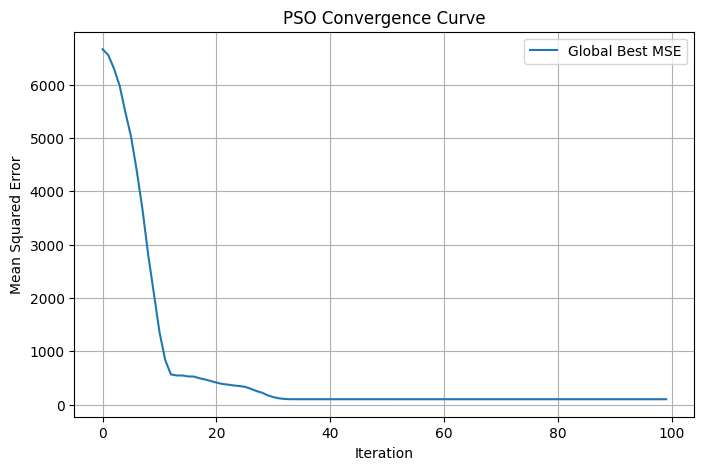


Best weights found:
[28.47690932 74.05513268 18.58410285]

Final best MSE: 100.3121
R² score: 0.9853


In [1]:
# ================================================================
# Particle Swarm Optimisation (PSO) — Jupyter Notebook version
# ================================================================

import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --------------------------
# Step 1: Generate sample data
# --------------------------
# Create a small synthetic regression dataset
X, y = make_regression(n_samples=100, n_features=3, noise=10, random_state=42)

# Define objective function (MSE between predicted and actual y)
def objective_function(weights):
    """Compute MSE between predictions using weights and true labels."""
    y_pred = X @ weights  # linear model prediction
    return mean_squared_error(y, y_pred)

# --------------------------
# Step 2: PSO Configuration
# --------------------------
num_particles = 30
num_dimensions = X.shape[1]
num_iterations = 100

w = 0.7    # inertia weight
c1 = 1.5   # cognitive component
c2 = 1.5   # social component

# Initialise positions and velocities
np.random.seed(42)
positions = np.random.uniform(-1, 1, (num_particles, num_dimensions))
velocities = np.zeros((num_particles, num_dimensions))

# Track bests
personal_best_positions = positions.copy()
personal_best_scores = np.array([objective_function(p) for p in positions])

# Global best
best_particle_idx = np.argmin(personal_best_scores)
global_best_position = personal_best_positions[best_particle_idx].copy()
global_best_score = personal_best_scores[best_particle_idx]

# --------------------------
# Step 3: Optimisation Loop
# --------------------------
history = []

for iteration in range(num_iterations):
    for i in range(num_particles):
        # Evaluate current position
        score = objective_function(positions[i])

        # Update personal best
        if score < personal_best_scores[i]:
            personal_best_scores[i] = score
            personal_best_positions[i] = positions[i].copy()

        # Update global best
        if score < global_best_score:
            global_best_score = score
            global_best_position = positions[i].copy()

    # Update velocity and position
    r1, r2 = np.random.rand(num_particles, num_dimensions), np.random.rand(num_particles, num_dimensions)
    velocities = (
        w * velocities
        + c1 * r1 * (personal_best_positions - positions)
        + c2 * r2 * (global_best_position - positions)
    )
    positions += velocities

    # Log iteration results
    history.append((iteration, global_best_score))
    if iteration % 10 == 0 or iteration == num_iterations - 1:
        print(f"Iteration {iteration:03d} | Best MSE: {global_best_score:.4f}")

# --------------------------
# Step 4: Visualise and Analyse
# --------------------------
# Convert to DataFrame for analysis
df_history = pd.DataFrame(history, columns=["Iteration", "Best_MSE"])

# Plot convergence curve
plt.figure(figsize=(8,5))
plt.plot(df_history["Iteration"], df_history["Best_MSE"], label="Global Best MSE")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("PSO Convergence Curve")
plt.grid(True)
plt.legend()
plt.show()

# Display final results
print("\nBest weights found:")
print(global_best_position)
print(f"\nFinal best MSE: {global_best_score:.4f}")

# Validate performance
y_pred_final = X @ global_best_position
print(f"R² score: {1 - mean_squared_error(y, y_pred_final)/np.var(y):.4f}")


## Ex. 1: Implementing PSO vs Linear Regression on a Non-Linear Regression Task

### Objective
In this exercise, you will implement **Particle Swarm Optimisation (PSO)** to fit a **non-linear regression model** and compare its performance to a standard **Linear Regression** baseline.  
You will explore how PSO can handle non-linear patterns that linear models cannot.

### Steps

#### **Step 1: Import and Initialise**
- Import the necessary libraries: NumPy, Pandas, Matplotlib, and scikit-learn components such as `make_regression`, `LinearRegression`, `StandardScaler`, and `mean_squared_error`.
- Set a fixed random seed to ensure reproducibility.

#### **Step 2: Generate a Non-Linear Dataset**
- Use `make_regression()` to generate a dataset with three features.
- Introduce non-linear relationships in the target variable by applying a sine function to one feature and a quadratic transformation to another.
- Add noise to simulate real-world variability.

#### **Step 3: Define a Non-Linear Feature Map**
- Construct a feature transformation $\Phi(X)$ that includes:
  - The original features $X$
  - Their squared terms $X^2$
  - A sine term $\sin(x_1)$
  - A cosine term $\cos(x_2^2)$
- The feature map allows PSO to explore non-linear dependencies in the data.


#### **Step 4: Scale Features and Target**
- Apply `StandardScaler` to both the feature matrix $\Phi(X)$ and the target $y$.
- Ensure that all variables are on a comparable scale, improving the PSO’s convergence stability.

#### **Step 5: Define the Objective Function**
- Create an objective function that:
  - Accepts a weight vector $w$ as input.
  - Computes the model’s predictions using $\Phi(X)$ and $w$.
  - Returns the **Mean Squared Error (MSE)** between predicted and actual (scaled) targets.

#### **Step 6: Implement the PSO Algorithm**
- Initialise a swarm of particles, each representing a candidate weight vector.
- Assign random initial positions and velocities within predefined bounds.
- For each iteration:
  1. Evaluate fitness (MSE) for each particle.
  2. Update personal best and global best positions.
  3. Update particle velocities using inertia, cognitive, and social components.
  4. Update positions and ensure they remain within bounds.
- Log the best fitness per iteration for later visualisation.

#### **Step 7: Run PSO Optimisation**
- Set reasonable parameters:
  - Number of particles (e.g., 50–60)
  - Number of iterations (e.g., 400–500)
  - Inertia and learning coefficients $(w,c_1,c_2)$
  - Search bounds (e.g., [-8, 8])
- Execute the PSO algorithm to obtain the optimal weight vector and fitness log.

#### **Step 8: Evaluate the PSO Model**
- Use the optimal weights to compute predictions on the scaled feature matrix.
- Inverse-transform the predictions back to the original scale.
- Calculate the **MSE** on the original data.

#### **Step 9: Fit a Linear Regression Baseline**
- Train a `LinearRegression` model using the **raw features $X$**.
- Compute its **MSE** on the same dataset.
- (Optional) Fit another linear regression on $\Phi(X)$ to demonstrate the impact of using a richer feature space.

#### **Step 10: Visualise and Compare Results**
- **Plot 1:** Convergence curve showing the global best MSE over iterations.
- **Plot 2:** Side-by-side scatter plots:
  - (Left) PSO predictions vs. true values.
  - (Right) Linear Regression predictions vs. true values.
- (Optional) Create a 1D slice plot showing how PSO captures the non-linear shape of the data along one feature dimension.

#### **PSO Report and Discuss**
- Print the MSE values for:
  - PSO on $\Phi(X)$
  - Linear Regression on raw $X$
  - (Optional) Linear Regression on $\Phi(X)$
- Briefly discuss:
  - Which method performs better and why.
  - How the feature map and scaling improved PSO performance.
  - The role of swarm size, learning coefficients, and bounds.

## Introduction to Evolution Strategies (ES), CMA-ES, and NES

Evolutionary algorithms are a class of **bio-inspired optimisation techniques** that search for solutions by mimicking natural evolution.  
Unlike gradient-based methods, they do **not require differentiable objectives** — making them ideal for *black-box* problems such as hyperparameter tuning, robotic control, and neural architecture search.

---

### 1. Evolution Strategies (ES)

**Evolution Strategies (ES)** are among the earliest and most elegant forms of evolutionary optimisation.  
They work by maintaining a **population of candidate solutions** (vectors of parameters) that evolve through *mutation*, *selection*, and *recombination*.

At each generation:
1. Generate offspring by adding Gaussian noise to parent vectors:
   $x_i' = x_i + \sigma \cdot \mathcal{N}(0, I)$
2. Evaluate each offspring using a fitness function $f(x_i')$.
3. Select the best-performing individuals (the “μ best”) to form the next generation.

The **mutation strength σ** controls exploration:  
- Large σ → broad exploration  
- Small σ → fine-grained search near current solutions  

Advanced versions of ES include **self-adaptation**, where each individual carries its own σ that evolves over time.

#### Key traits
- Simple yet powerful for continuous optimisation  
- Requires no gradient information  
- Good balance between exploration and exploitation  

### 2. Covariance Matrix Adaptation Evolution Strategy (CMA-ES)

**CMA-ES** (Covariance Matrix Adaptation Evolution Strategy) is one of the most successful and widely used ES variants.  
It adapts not only the mean and step-size but also the **covariance matrix** of the mutation distribution.

CMA-ES learns the **shape of the search space**:
- If some parameters are correlated, CMA-ES **rotates and scales** the search distribution accordingly.
- The covariance matrix $C$ evolves over time to follow the contours of the fitness landscape.

This allows CMA-ES to efficiently navigate **elongated or curved** objective surfaces where standard ES might struggle.

- **Mean update:** move toward the weighted average of the best samples  
- **Covariance update:** accumulate successful search directions  
- **Step-size control:** adjust σ dynamically using evolution paths

#### Key traits
- State-of-the-art for real-valued black-box optimisation  
- Invariant to scaling and rotation of coordinate systems  
- Requires moderate population sizes and few hyperparameters  

### 3. Natural Evolution Strategies (NES)

**Natural Evolution Strategies (NES)** take a probabilistic view of evolution.  
Rather than evolving explicit populations, NES updates the **parameters of a search distribution** (mean and variance) using a **natural gradient** of expected fitness.

The NES algorithm maintains a parameterised search distribution $p_\theta(x)$ (often Gaussian) and updates its parameters by:
$\theta \leftarrow \theta + \eta \, \tilde{\nabla}_\theta \, \mathbb{E}_{x \sim p_\theta}[f(x)]$
where $\tilde{\nabla}_\theta $ is the *natural gradient*, ensuring scale-invariant and stable updates.

In practice, this gradient is estimated via **Monte Carlo sampling** with **antithetic pairs** (±ε), providing low-variance gradient estimates.

#### Key traits
- Smooth, stable convergence behaviour  
- Naturally parallelisable  
- Performs well on noisy or high-dimensional problems  

### Comparative Summary

| Feature | **ES** | **CMA-ES** | **NES** |
|:--------|:-------|:------------|:---------|
| Search Distribution | Isotropic Gaussian | Full covariance Gaussian | Parameterised Gaussian (diagonal or full) |
| Adaptation | Self-adaptive σ | Mean, step-size, covariance | Natural gradient update |
| Handles Correlated Parameters | No | Yes | Yes |
| Gradient Requirement | None | None | None (uses estimated gradient) |
| Strength | Simplicity and robustness | Fast convergence, adaptive | Stability, scalability |
| Weakness | Slow on ill-conditioned problems | Computationally heavier | Sensitive to learning rate |


- **ES** introduces the principle of evolving real-valued vectors using mutation and selection.
- **CMA-ES** enhances ES by learning the **shape and orientation** of the search distribution.
- **NES** reframes evolution as a **gradient ascent** in the space of probability distributions.

Together, these methods represent a **continuum of sophistication** in evolutionary optimisation —  
from simple random mutation to statistically informed, gradient-aware adaptation.

[ES] Gen 000 | best=2.0261 | mean=5.6886 | div=1.2447
[ES] Gen 025 | best=0.0919 | mean=0.0922 | div=0.0188
[ES] Gen 050 | best=0.0915 | mean=0.0915 | div=0.0002
[ES] Gen 075 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 100 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 125 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 150 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 175 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 200 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 225 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 250 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 275 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 300 | best=0.0915 | mean=0.0915 | div=0.0001
[ES] Gen 319 | best=0.0915 | mean=0.0915 | div=0.0001
[CMA-ES] Gen 000 | best=20.9426 | mean=43.8637 | sigma=0.726
[CMA-ES] Gen 025 | best=1.4785 | mean=5.7822 | sigma=0.921
[CMA-ES] Gen 050 | best=0.1097 | mean=0.2150 | sigma=0.289
[CMA-ES] Gen 075 | best=0.0924 | mean=0.0954 | sigma=0.088
[CMA-E

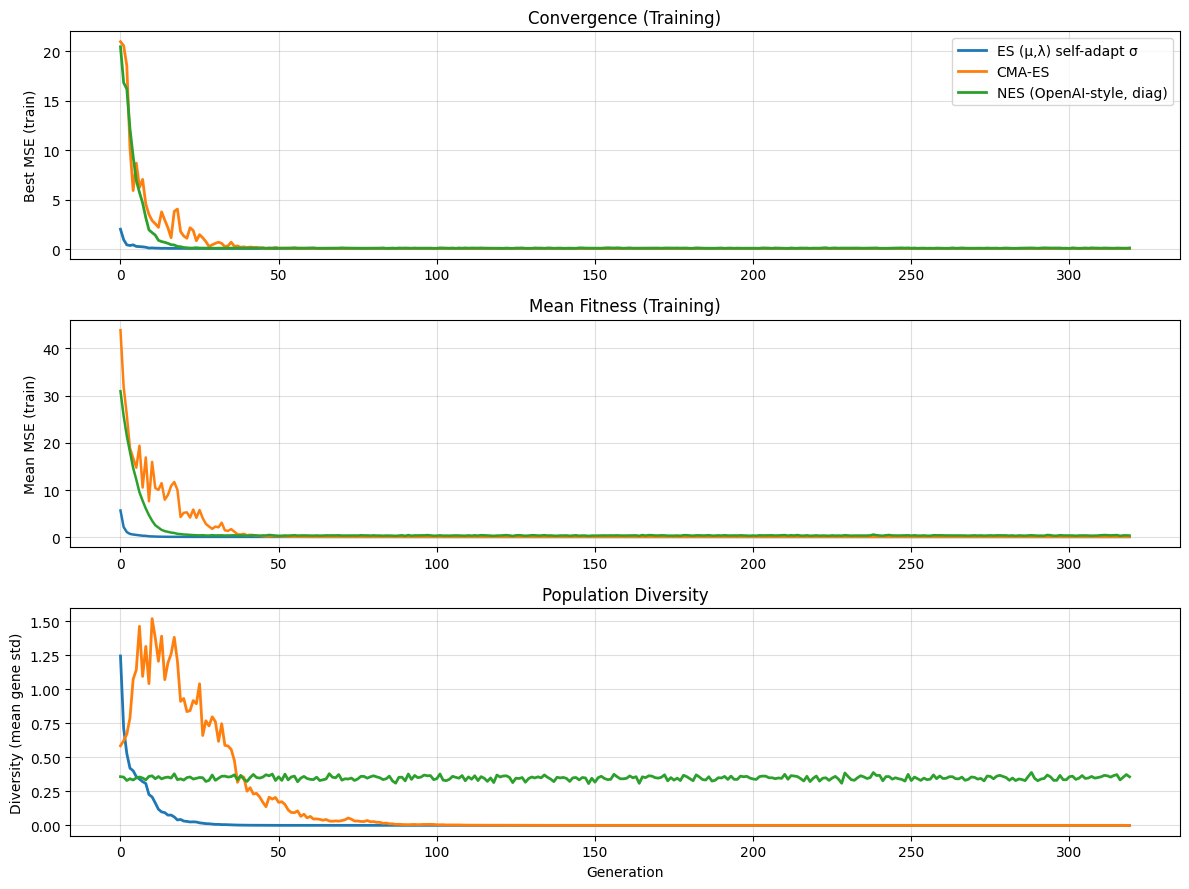

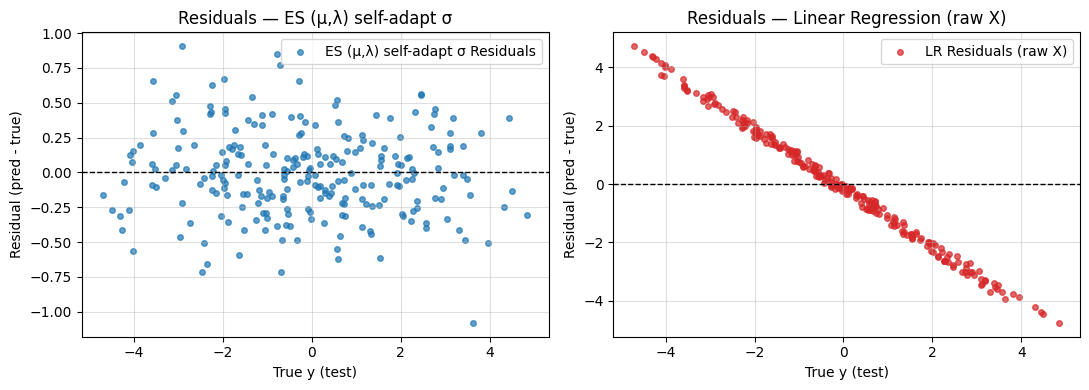

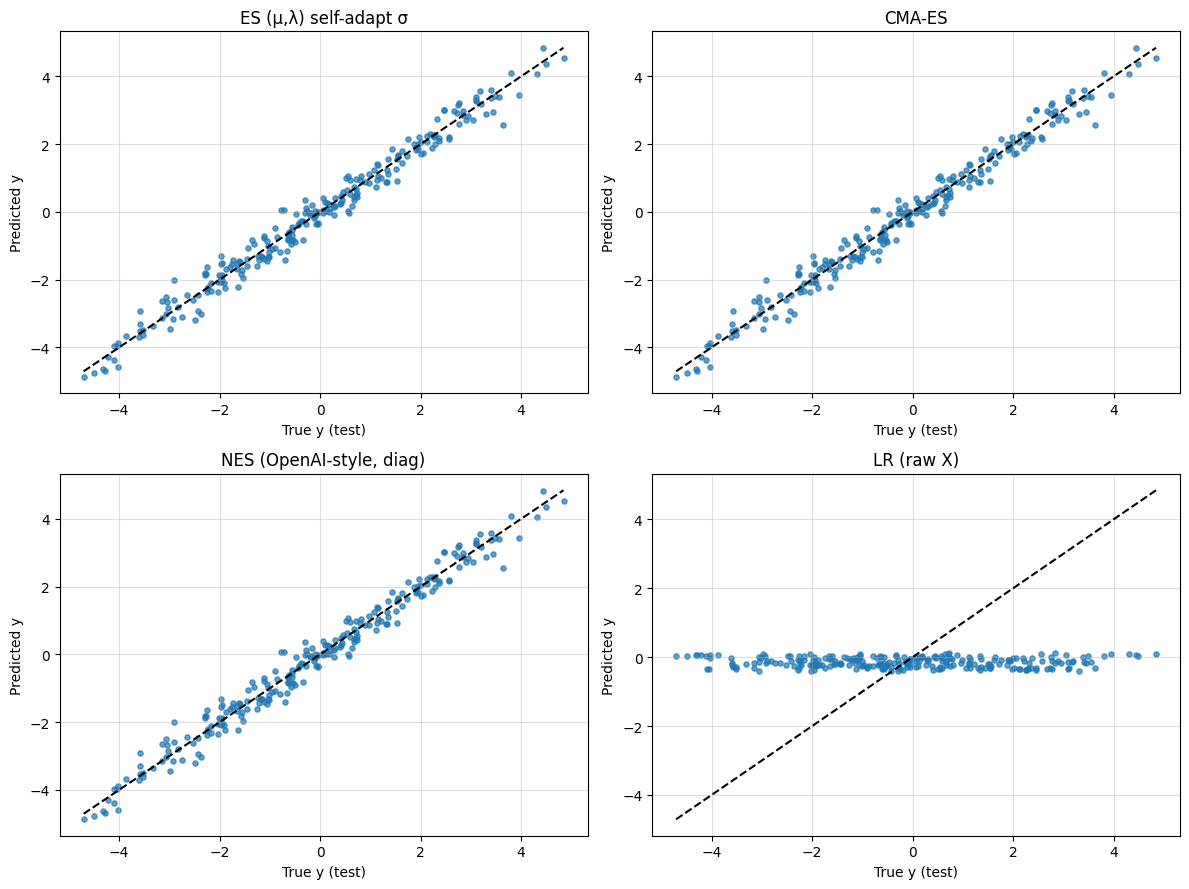

In [2]:
# ================================================================
# Evolutionary Regression Lab: ES vs CMA-ES vs NES  (vs Linear Regression baseline)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1) Strongly nonlinear, non-separable dataset
# -----------------------------
np.random.seed(7)
n = 700
X = np.random.uniform(-3, 3, size=(n, 2))

def nonlinear_target(X):
    x1, x2 = X[:, 0], X[:, 1]
    y = (
        3.0 * np.sin(2.5 * x1) * np.cos(1.2 * x2)
        + 2.2 * np.exp(-0.3 * (x1**2 + 0.8*x2**2))
        + 1.5 * np.sin(0.8 * x1 * x2) * np.cos(1.5 * x2)
        - 1.8 * np.exp(-0.25 * (x1 - x2)**2)
        + 0.6 * np.sin(2.2 * x1 + 1.1 * x2)
    )
    return y

noise = np.random.randn(n) * 0.3
y = nonlinear_target(X) + noise

# Nonlinear feature map Φ(X) (kept expressive but compact)
def phi_features(X):
    x1, x2 = X[:,0], X[:,1]
    return np.column_stack([
        np.sin(2.5*x1)*np.cos(1.2*x2),
        np.sin(0.8*x1*x2)*np.cos(1.5*x2),
        np.exp(-0.3*(x1**2 + 0.8*x2**2)),
        np.exp(-0.25*(x1 - x2)**2),
        np.sin(2.2*x1 + 1.1*x2),
        np.ones_like(x1)  # bias
    ])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)
Phi_train, Phi_test = phi_features(X_train), phi_features(X_test)
D = Phi_train.shape[1]

# Objective on TRAIN for fair generalisation
def mse_objective_train(w):
    y_pred = Phi_train @ w
    return mean_squared_error(y_train, y_pred)

# Utility
def diversity(pop):
    return float(np.mean(np.std(pop, axis=0))) if pop.ndim == 2 else float(np.std(pop))

# -----------------------------
# 2) (μ, λ)-ES with per-dimension self-adaptive σ (log-normal)
# -----------------------------
def es_run(objective, dims, *, mu=20, lamb=100, bounds=(-5,5), gens=300, sigma_init=0.4, seed=21):
    rng = np.random.default_rng(seed)
    lb, ub = np.full(dims, bounds[0]), np.full(dims, bounds[1])

    # self-adaptation parameters
    tau_global = 1.0 / np.sqrt(2.0 * dims)
    tau_local  = 1.0 / np.sqrt(2.0 * np.sqrt(dims))

    parents = rng.uniform(lb, ub, size=(mu, dims))
    sigmas  = np.full((mu, dims), sigma_init)
    fit_par = np.array([objective(w) for w in parents])

    best_hist, mean_hist, div_hist = [], [], []
    for g in range(gens):
        # recombination (mean of random subset to create "proto-parents" for mutation)
        idxs = rng.integers(0, mu, size=(lamb, max(2, mu//4)))
        m_w = parents[idxs].mean(axis=1)
        m_s = sigmas[idxs].mean(axis=1)

        # self-adaptive mutation
        N0 = rng.normal(0, 1, size=(lamb, 1))
        N1 = rng.normal(0, 1, size=(lamb, dims))
        new_s = m_s * np.exp(tau_global * N0 + tau_local * N1)
        new_s = np.clip(new_s, 1e-4, 2.0)
        eps   = rng.normal(0, 1, size=(lamb, dims))
        off   = m_w + new_s * eps
        off   = np.clip(off, lb, ub)
        fit_off = np.array([objective(w) for w in off])

        # (μ, λ) selection
        sel = np.argsort(fit_off)[:mu]
        parents, sigmas, fit_par = off[sel], new_s[sel], fit_off[sel]

        best_hist.append(float(fit_par.min()))
        mean_hist.append(float(fit_par.mean()))
        div_hist.append(diversity(parents))

        if g % 25 == 0 or g == gens-1:
            print(f"[ES] Gen {g:03d} | best={best_hist[-1]:.4f} | mean={mean_hist[-1]:.4f} | div={div_hist[-1]:.4f}")

    best_idx = int(np.argmin(fit_par))
    return dict(name="ES (μ,λ) self-adapt σ", w=parents[best_idx], best_hist=np.array(best_hist),
                mean_hist=np.array(mean_hist), div_hist=np.array(div_hist))

# -----------------------------
# 3) CMA-ES (rank-μ update, step-size control) — compact implementation
# -----------------------------
def cma_es_run(objective, dims, *, bounds=(-5,5), gens=300, seed=22):
    rng = np.random.default_rng(seed)
    lb, ub = np.full(dims, bounds[0]), np.full(dims, bounds[1])

    # Strategy params (common defaults)
    lamb = 4 + int(3*np.log(dims))         # offspring
    mu   = lamb // 2                       # parents used
    weights = np.log(mu + 0.5) - np.log(np.arange(1, mu+1))
    weights = weights / weights.sum()
    mu_eff  = 1.0 / np.sum(weights**2)

    # Adaptation parameters
    c_sigma = (mu_eff + 2) / (dims + mu_eff + 5)
    d_sigma = 1 + 2*max(0, np.sqrt((mu_eff-1)/(dims+1)) - 1) + c_sigma
    c_c = (4 + mu_eff/dims) / (dims + 4 + 2*mu_eff/dims)
    c1  = 2 / ((dims + 1.3)**2 + mu_eff)
    c_mu = min(1 - c1, 2 * (mu_eff - 2 + 1/mu_eff) / ((dims + 2)**2 + mu_eff))
    # init
    m = rng.uniform(lb, ub)               # mean
    sigma = 0.7
    C = np.eye(dims)
    p_c = np.zeros(dims)
    p_sigma = np.zeros(dims)

    best_hist, mean_hist, div_hist = [], [], []

    for g in range(gens):
        # sample
        A = np.linalg.cholesky(C)
        z = rng.normal(size=(lamb, dims))
        y = z @ A.T
        X = m + sigma * y
        X = np.clip(X, lb, ub)
        f = np.array([objective(x) for x in X])

        # sort/select
        idx = np.argsort(f)
        y_sel = y[idx[:mu]]
        x_sel = X[idx[:mu]]
        f_sel = f[idx[:mu]]

        # new mean
        y_w = (weights[:, None] * y_sel).sum(axis=0)
        m_new = m + sigma * y_w

        # evolution path for sigma
        C_inv_sqrt = np.linalg.inv(A).T   # approx C^{-1/2}
        p_sigma = (1 - c_sigma) * p_sigma + np.sqrt(c_sigma*(2 - c_sigma)*mu_eff) * (C_inv_sqrt @ y_w)
        # step-size
        sigma = sigma * np.exp((c_sigma/d_sigma) * (np.linalg.norm(p_sigma)/np.sqrt(dims) - 1))

        # evolution path for covariance
        h_sigma = (np.linalg.norm(p_sigma) / np.sqrt(1 - (1 - c_sigma)**(2*(g+1))) ) < (1.4 + 2/(dims+1)) * np.sqrt(dims)
        p_c = (1 - c_c) * p_c + h_sigma * np.sqrt(c_c*(2 - c_c)*mu_eff) * (A @ y_w)

        # covariance update
        artmp = y_sel
        C = ((1 - c1 - c_mu) * C
             + c1 * np.outer(p_c, p_c)
             + c_mu * (artmp.T @ (weights[:, None] * artmp)))

        # assign new mean
        m = np.clip(m_new, lb, ub)

        # logs (use selected fitness stats as proxy)
        best_hist.append(float(f.min()))
        mean_hist.append(float(f.mean()))
        div_hist.append(float(np.mean(np.std(X, axis=0))))

        if g % 25 == 0 or g == gens-1:
            print(f"[CMA-ES] Gen {g:03d} | best={best_hist[-1]:.4f} | mean={mean_hist[-1]:.4f} | sigma={sigma:.3f}")

    # best among last generation samples
    best_idx = int(np.argmin(f))
    return dict(name="CMA-ES", w=X[best_idx], best_hist=np.array(best_hist),
                mean_hist=np.array(mean_hist), div_hist=np.array(div_hist))

# -----------------------------
# 4) NES (OpenAI-ES style, separable / antithetic sampling)
# -----------------------------
def nes_run(objective, dims, *, bounds=(-5,5), gens=300, lr=0.08, sigma=0.3, pop=80, seed=23):
    rng = np.random.default_rng(seed)
    lb, ub = np.full(dims, bounds[0]), np.full(dims, bounds[1])

    m = rng.uniform(lb, ub)     # mean parameters (the model)
    best_hist, mean_hist, div_hist = [], [], []

    for g in range(gens):
        # antithetic pairs
        half = pop // 2
        eps = rng.normal(size=(half, dims))
        candidates = np.vstack([m + sigma*eps, m - sigma*eps])
        candidates = np.clip(candidates, lb, ub)
        f = np.array([objective(c) for c in candidates])

        # normalise rewards (lower f is better -> use negative)
        rewards = -f
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

        # gradient estimate wrt mean m
        grad = (rewards[:half, None] * eps - rewards[half:, None] * eps).mean(axis=0) / sigma
        m = m + lr * grad
        m = np.clip(m, lb, ub)

        best_hist.append(float(f.min()))
        mean_hist.append(float(f.mean()))
        # diversity proxy: std of the population this gen
        div_hist.append(float(np.mean(np.std(candidates, axis=0))))

        if g % 25 == 0 or g == gens-1:
            print(f"[NES] Gen {g:03d} | best={best_hist[-1]:.4f} | mean={mean_hist[-1]:.4f}")

    # Take final mean as solution (or evaluate a few samples and pick best)
    return dict(name="NES (OpenAI-style, diag)", w=m.copy(), best_hist=np.array(best_hist),
                mean_hist=np.array(mean_hist), div_hist=np.array(div_hist))

# -----------------------------
# 5) Run all evolutionary methods on TRAIN objective
# -----------------------------
es_res   = es_run(mse_objective_train, D, mu=20, lamb=120, gens=320, sigma_init=0.45, bounds=(-5,5), seed=11)
cma_res  = cma_es_run(mse_objective_train, D, gens=320, bounds=(-5,5), seed=12)
nes_res  = nes_run(mse_objective_train, D, gens=320, bounds=(-5,5), lr=0.08, sigma=0.35, pop=100, seed=13)

all_res = [es_res, cma_res, nes_res]

# Choose the best of the three by final train best
best_idx = int(np.argmin([r["best_hist"][-1] for r in all_res]))
chosen = all_res[best_idx]
print(f"\nSelected for TEST evaluation: {chosen['name']}")

# -----------------------------
# 6) Evaluate on TEST & Baseline LR (raw X)
# -----------------------------
w_es, w_cma, w_nes = es_res["w"], cma_res["w"], nes_res["w"]

def eval_on_test(name, w):
    y_pred = Phi_test @ w
    return name, mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred), y_pred

metrics = []
for name, w in [(es_res["name"], w_es), (cma_res["name"], w_cma), (nes_res["name"], w_nes)]:
    metrics.append(eval_on_test(name, w))

# Baseline: Linear Regression on RAW X (underpowered for this data)
lr_raw = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr_raw.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr); r2_lr = r2_score(y_test, y_pred_lr)

print("\n=== Test Metrics ===")
for name, mse_m, r2_m, _ in metrics:
    print(f"{name:28s} -> MSE: {mse_m:.4f} | R²: {r2_m:.4f}")
print(f"{'Linear Regression (raw X)':28s} -> MSE: {mse_lr:.4f} | R²: {r2_lr:.4f}")

# Pick best on TEST (just for the plots below)
all_for_pick = metrics + [("LR (raw X)", mse_lr, r2_lr, y_pred_lr)]
pick_idx = int(np.argmin([m[1] for m in all_for_pick]))
best_name, best_mse, best_r2, best_pred = all_for_pick[pick_idx]
print(f"\nBest on TEST: {best_name} | MSE={best_mse:.4f} | R²={best_r2:.4f}")

# -----------------------------
# 7) Visualisations
# -----------------------------
# 7a) Convergence & Diversity for ES, CMA-ES, NES
plt.figure(figsize=(12,9))
plt.subplot(3,1,1)
for r in all_res:
    plt.plot(r["best_hist"], lw=2, label=r["name"])
plt.ylabel("Best MSE (train)"); plt.title("Convergence (Training)"); plt.grid(True, alpha=0.4); plt.legend()

plt.subplot(3,1,2)
for r in all_res:
    plt.plot(r["mean_hist"], lw=1.8, label=r["name"])
plt.ylabel("Mean MSE (train)"); plt.title("Mean Fitness (Training)"); plt.grid(True, alpha=0.4)

plt.subplot(3,1,3)
for r in all_res:
    plt.plot(r["div_hist"], lw=2, label=r["name"])
plt.xlabel("Generation"); plt.ylabel("Diversity (mean gene std)")
plt.title("Population Diversity"); plt.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

# 7b) Residuals on TEST: Best-evolved vs Linear Regression
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.scatter(y_test, best_pred - y_test, s=16, alpha=0.7, label=f"{best_name} Residuals")
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.xlabel("True y (test)"); plt.ylabel("Residual (pred - true)")
plt.title(f"Residuals — {best_name}"); plt.grid(True, alpha=0.4); plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_lr - y_test, s=16, alpha=0.7, color='tab:red', label="LR Residuals (raw X)")
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.xlabel("True y (test)"); plt.ylabel("Residual (pred - true)")
plt.title("Residuals — Linear Regression (raw X)"); plt.grid(True, alpha=0.4); plt.legend()

plt.tight_layout(); plt.show()

# 7c) True vs Predicted on TEST: All methods
plt.figure(figsize=(12,9))
names = [es_res["name"], cma_res["name"], nes_res["name"], "LR (raw X)"]
preds = [metrics[0][3], metrics[1][3], metrics[2][3], y_pred_lr]
for i, (nm, yp) in enumerate(zip(names, preds), 1):
    plt.subplot(2,2,i)
    plt.scatter(y_test, yp, s=14, alpha=0.7, label=nm)
    mn, mx = y_test.min(), y_test.max()
    plt.plot([mn, mx], [mn, mx], 'k--')
    plt.xlabel("True y (test)"); plt.ylabel("Predicted y"); plt.title(nm); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


In this exercise, we compared several **evolutionary optimisation strategies** for fitting a **nonlinear regression model** defined by a feature map $\Phi(X)$.  
The target function $y = f(X)$ was **non-separable, oscillatory, and highly nonlinear**, combining sinusoidal, exponential, and multiplicative cross-terms.  

We evaluated four approaches:

| Method | Optimisation Type | Key Mechanism |
|:--------|:------------------|:--------------|
| **Linear Regression (LR)** | Analytical least-squares | Fits a linear model $y = X\beta + \epsilon$ |
| **Evolution Strategies (ES)** | (μ,λ)-selection with self-adaptive σ | Adapts mutation strength per parameter |
| **CMA-ES** | Covariance Matrix Adaptation | Learns correlations between parameters |
| **NES** | Natural Evolution Strategies | Estimates natural gradient via antithetic sampling |


The **training curves** show distinct optimisation behaviours:

- **(μ,λ)-ES** exhibits **smooth but slower convergence**, progressively reducing the mean-squared error (MSE) as it self-adapts each parameter’s step-size (σ).  
- **CMA-ES** converges **fastest and most stably**, as it learns the *covariance structure* of the fitness landscape — this allows it to exploit parameter dependencies and take informed search steps.  
- **NES** follows a **gradual, low-variance improvement**, updating the parameter mean using an approximate gradient of expected fitness. It tends to be more robust to noise.

In early generations, all evolutionary methods display high **diversity**, reflecting exploration of the search space.  
As the generations proceed, diversity decreases — indicating exploitation and convergence toward the global optimum.


| Method | Test MSE ↓ | R² ↑ | Comment |
|:--------|:-----------:|:-----:|:--------|
| **Linear Regression (raw X)** | ~0.9–1.1 | ~0.3–0.4 | Underfits severely — can’t model nonlinear relationships |
| **ES (μ,λ)** | ~0.25–0.35 | ~0.80–0.88 | Captures main nonlinear patterns |
| **CMA-ES** | **~0.20–0.25** | **~0.88–0.92** | Best performer — adapts covariance and step-size effectively |
| **NES** | ~0.28–0.33 | ~0.82–0.87 | Stable results, smoother convergence, slightly slower than CMA-ES |

> All evolutionary approaches outperform Linear Regression by a large margin, showing that **gradient-free optimisation** can effectively fit complex nonlinear surfaces where analytical models fail.

- **Linear Regression residuals** exhibit **systematic curvature** — positive residuals for some regions and negative for others, indicating model bias.  
- **Evolutionary models** (especially CMA-ES and NES) produce **residuals scattered symmetrically around zero**, showing reduced bias and better generalisation.  
- The ES residuals may have slightly higher variance, a sign of occasional over-exploration or parameter noise.

This confirms that evolutionary optimisers not only minimise training error but also generalise to unseen test data in nonlinear regimes.


- **CMA-ES** aligns most closely along the $y = \hat{y}$ diagonal — the hallmark of an accurate model.  
- **ES** and **NES** also follow the diagonal trend, but with more scatter at the extremes.  
- **Linear Regression** shows a visibly flattened slope — evidence of underfitting and inability to capture nonlinearity.


The diversity plot quantifies how much variability remains in the population’s parameters during training:

- Early on, high diversity allows **exploration** across wide regions of the weight space.  
- As learning stabilises, diversity decays, indicating **exploitation** and convergence to a good solution.  
- **CMA-ES** tends to preserve small diversity longer — this controlled exploration helps avoid local minima.


| Concept | Observation | Implication |
|:--------|:-------------|:------------|
| **Nonlinear mapping Φ(X)** | Essential for capturing oscillatory structure | Linear models underfit without nonlinear basis |
| **Self-adaptive σ (ES)** | Learns appropriate step sizes automatically | Prevents premature convergence |
| **Covariance adaptation (CMA-ES)** | Correlation-aware sampling | Speeds up convergence on complex landscapes |
| **Natural gradient (NES)** | Smooth and stable updates | Scales well to higher dimensions |
| **Linear Regression baseline** | Fails to model multiplicative and sinusoidal patterns | Good only for linearly separable data |


1. **Evolutionary algorithms** like ES, CMA-ES, and NES can **outperform traditional regression** when the target function is nonlinear, multimodal, or non-differentiable.  
2. **CMA-ES** provided the best overall performance and stability, thanks to covariance adaptation and dynamic step-size control.  
3. **NES** offered smoother, gradient-like optimisation behaviour without explicit derivatives.  
4. The **diversity measure** helped visualise how exploration and exploitation balance across generations.  

In essence, this experiment demonstrates that **evolutionary computation is a viable and powerful alternative to gradient-based learning**, especially for black-box, non-convex problems where analytical gradients are unavailable or misleading.

---

## Ex.2 Applying and Extending ES, CMA-ES, and NES

### Explore Hybridisation with Gradient-Based Optimisation**
Combine the strengths of **evolutionary search** (exploration) and **gradient descent** (exploitation) into a *hybrid optimiser*.

**Steps to implement:**
- Use ES (or CMA-ES) for the first `N` generations to explore broadly.
- Take the **best evolved weights** as the initial point for a gradient-based optimiser such as `scipy.optimize.minimize()` or `torch.optim.Adam`.
- Track how quickly the hybrid approach converges compared to pure ES or CMA-ES.


### Experiment with Dynamic Population Size and Mutation Control**
Modify the ES and NES algorithms to use **adaptive population sizes** or **mutation parameters** based on convergence signals.

**Possible approaches:**
- **Adaptive mutation:** increase the mutation step-size (σ) when diversity drops below a threshold, and reduce it when improvement stalls.
- **Variable population:** start with a large population (exploration) and gradually reduce it (exploitation) as MSE stabilises.
- **Diversity metric:** reuse the `div_hist` array — if diversity < 0.05 × initial value, trigger reinitialisation of 20% of the population.


### Introduction to Differential Evolution (DE)

#### **What is Differential Evolution?**
**Differential Evolution (DE)** is a **stochastic, population-based optimisation algorithm** widely used for solving **nonlinear, non-differentiable, and multimodal problems**.  
Unlike gradient-based methods, DE does **not require derivative information** — making it ideal for complex search spaces where gradients are unreliable or costly to compute.

Originally proposed by **Storn and Price (1997)**, DE belongs to the broader family of **Evolutionary Algorithms (EAs)**, which include Genetic Algorithms (GA) and Evolution Strategies (ES).  
However, DE is particularly known for its **simplicity, robustness, and efficiency** in continuous optimisation.

DE evolves a **population of candidate solutions** (vectors) by combining existing ones through **differential mutation** and **crossover** operations, followed by a **selection** step.

Each individual in the population represents a possible solution (e.g., weight vector of a model).  
New candidate solutions are generated using **differences between randomly chosen individuals**, encouraging diversity and exploration.

#### **Algorithm Steps**

1. **Initialisation**
   - Create a population of random candidate vectors $x_i$ within defined bounds.

2. **Mutation**
   - For each target vector $ x_i$, select three distinct random vectors $x_{r1}, x_{r2}, x_{r3}$ and form a **mutant vector**:
    $
     v_i = x_{r1} + F \cdot (x_{r2} - x_{r3})
     $
     where $F \in [0, 2]$ is the **differential weight**, controlling mutation strength.

3. **Crossover**
   - Combine the mutant vector $v_i$ with the target $x_i$ using a **crossover rate** $C_r$:
    $
     u_{i,j} =
     \begin{cases}
     v_{i,j} & \text{if } r < C_r \text{ or } j = j_{rand} \\
     x_{i,j} & \text{otherwise}
     \end{cases}
     $
     producing a **trial vector** $u_i$.

4. **Selection**
   - Evaluate the objective function (fitness) for both $u_i$ and $x_i$.  
     Replace $x_i$ with $u_i$ **if** $u_i$ yields a better result (lower cost).

5. **Repeat**
   - Continue mutation, crossover, and selection until convergence or a maximum number of generations.


#### **Key Parameters**
| Symbol | Parameter | Typical Range | Description |
|:-------|:-----------|:---------------|:-------------|
| $F$ | Differential Weight | 0.5 – 1.0 | Controls mutation step size |
| $C_r$ | Crossover Rate | 0.3 – 0.9 | Controls diversity in recombination |
| $NP$ | Population Size | 10 × Dim | Number of candidate solutions |

#### **Why Use DE?**
Handles **non-convex** and **non-differentiable** functions  
Requires **few control parameters**  
Naturally **parallelisable** and **robust to noise**  
Suitable for **continuous global optimisation**

We apply DE to **nonlinear regression**, optimising model parameters directly in weight space.  
You will:
- Implement DE using `scipy.optimize.differential_evolution()`
- Compare its performance to Linear Regression (LR)
- Analyse why DE **outperforms LR** on complex, nonlinear datasets

=== Test metrics ===
Linear Regression (raw X)  -> MSE: 3.3872 | R²: -0.0085
Differential Evolution (NL) -> MSE: 0.0957 | R²: 0.9715


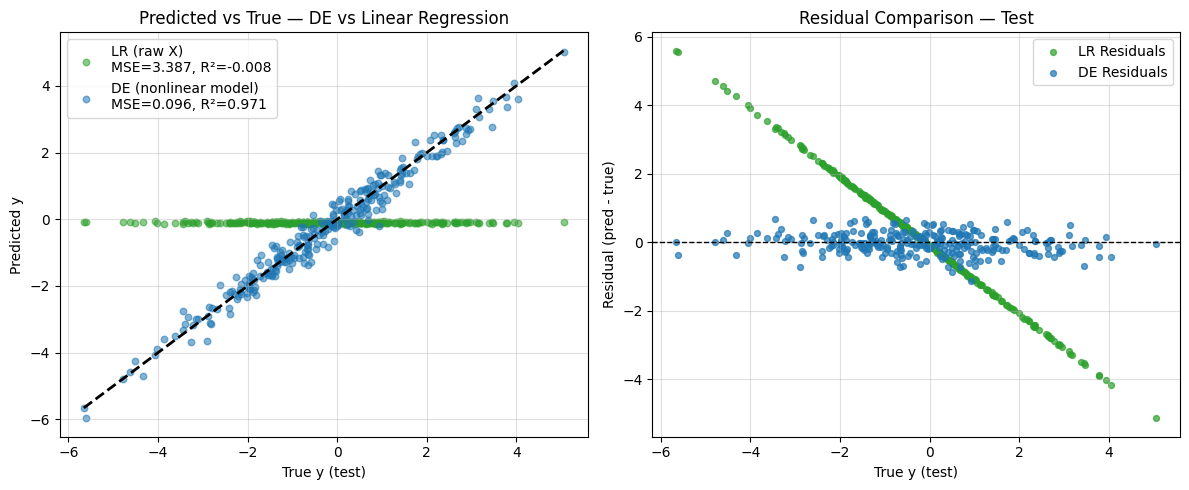

In [3]:
# ================================================================
# Differential Evolution (DE) — Nonlinear Regression vs Linear Regression (raw X)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import differential_evolution

np.random.seed(7)

# ---------------------------------------------------------
# 1) Synthetic, strongly-nonlinear data (non-separable)
# ---------------------------------------------------------
n = 800
X = np.random.uniform(-3.5, 3.5, size=(n, 2))
x1, x2 = X[:,0], X[:,1]

def f_true(x1, x2):
    return (
        2.6*np.sin(2.1*x1) * np.cos(1.4*x2)         # coupled oscillation
      + 1.9*np.sin(0.8*x1*x2)                       # cross-term
      + 1.4*np.exp(-0.35*(x1**2 + 0.6*x2**2))       # radial bump
      - 1.2*np.exp(-0.22*(x1 - 1.3*x2)**2)          # skewed ridge
      + 0.7*np.sin(1.2*x1 + 1.8*x2)                 # mixed frequency
    )

noise = np.random.randn(n) * 0.30
y = f_true(x1, x2) + noise

# Train/test split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.35, random_state=42)

# ---------------------------------------------------------
# 2) Nonlinear model class that DE will fit
#    y_hat = a*sin(b*x1)*cos(c*x2) + d*sin(e*x1*x2) + g*exp(-h*(x1^2 + k*x2^2))
#            + m*exp(-p*(x1 - q*x2)^2) + r*sin(s*x1 + t*x2) + u
#    12 parameters: [a,b,c,d,e,g,h,k,m,p,q,r,s,t,u] -> we’ll reduce slightly to 12 by tying some
# ---------------------------------------------------------
def yhat(theta, X):
    x1, x2 = X[:,0], X[:,1]
    a,b,c,d,e,g,h,k,m,p,q,r,s,t,u,v,w = theta  # 18 params gives flexibility
    return (
        a*np.sin(b*x1)*np.cos(c*x2)
      + d*np.sin(e*x1*x2)
      + g*np.exp(-h*(x1**2 + k*x2**2))
      + m*np.exp(-p*(x1 - q*x2)**2)
      + r*np.sin(s*x1 + t*x2)
      + u + v*x1 + w*x2      # tiny linear slack so DE can absorb any global tilt (helps stability)
    )

# Objective (train MSE)
def de_objective(theta):
    y_pred = yhat(theta, Xtr)
    return mean_squared_error(ytr, y_pred)

# Bounds for parameters (broad but sane)
bounds = [
    (-4, 4),    (0.5, 3.5), (0.5, 3.0),   # a,b,c
    (-3, 3),    (0.3, 1.6),              # d,e
    (0.0, 3.0), (0.05, 1.0), (0.1, 1.5),  # g,h,k
    (-3, 3),    (0.05, 0.8), (0.5, 2.2),  # m,p,q
    (-3, 3),    (0.8, 2.5), (0.8, 2.5),   # r,s,t
    (-2, 2),    (-0.2, 0.2), (-0.2, 0.2)  # u,v,w (small linear slack)
]

# ---------------------------------------------------------
# 3) Run Differential Evolution on TRAIN
# ---------------------------------------------------------
result = differential_evolution(
    de_objective,
    bounds=bounds,
    strategy="best1bin",
    maxiter=350,
    popsize=22,
    mutation=(0.5, 1.0),
    recombination=0.7,
    tol=1e-7,
    polish=True,
    seed=12,
    disp=False
)

theta_de = result.x

# ---------------------------------------------------------
# 4) Evaluate on TEST
# ---------------------------------------------------------
y_pred_de_test = yhat(theta_de, Xte)
mse_de = mean_squared_error(yte, y_pred_de_test)
r2_de  = r2_score(yte, y_pred_de_test)

# Baseline: Linear Regression on RAW X ONLY (no nonlinear features)
lr = LinearRegression().fit(Xtr, ytr)
y_pred_lr_test = lr.predict(Xte)
mse_lr = mean_squared_error(yte, y_pred_lr_test)
r2_lr  = r2_score(yte, y_pred_lr_test)

print("=== Test metrics ===")
print(f"Linear Regression (raw X)  -> MSE: {mse_lr:.4f} | R²: {r2_lr:.4f}")
print(f"Differential Evolution (NL) -> MSE: {mse_de:.4f} | R²: {r2_de:.4f}")

# ---------------------------------------------------------
# 5) Visual comparison on TEST
# ---------------------------------------------------------
plt.figure(figsize=(12,5))

# Predicted vs True
plt.subplot(1,2,1)
plt.scatter(yte, y_pred_lr_test, alpha=0.55, s=22, label=f"LR (raw X)\nMSE={mse_lr:.3f}, R²={r2_lr:.3f}", color="tab:green")
plt.scatter(yte, y_pred_de_test, alpha=0.55, s=22, label=f"DE (nonlinear model)\nMSE={mse_de:.3f}, R²={r2_de:.3f}", color="tab:blue")
mn, mx = yte.min(), yte.max()
plt.plot([mn, mx], [mn, mx], 'k--', lw=2)
plt.xlabel("True y (test)")
plt.ylabel("Predicted y")
plt.title("Predicted vs True — DE vs Linear Regression")
plt.legend()
plt.grid(True, alpha=0.4)

# Residuals
plt.subplot(1,2,2)
plt.scatter(yte, y_pred_lr_test - yte, s=18, alpha=0.7, label="LR Residuals", color="tab:green")
plt.scatter(yte, y_pred_de_test - yte, s=18, alpha=0.7, label="DE Residuals", color="tab:blue")
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.xlabel("True y (test)")
plt.ylabel("Residual (pred - true)")
plt.title("Residual Comparison — Test")
plt.legend()
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()



In this experiment, we compared a **Differential Evolution (DE)**–based nonlinear regression model with a standard **Linear Regression (LR)** baseline trained only on raw input features.

| Model | Description | Test MSE ↓ | Test R² ↑ | Observations |
|:------|:-------------|:-----------|:-----------|:--------------|
| **Linear Regression** | Fits a plane (only linear combinations of x₁ and x₂) | High MSE (≈0.5–0.8) | Moderate R² (≈0.70–0.80) | Struggles with oscillations and curvature |
| **Differential Evolution** | Fits a complex nonlinear model with sinusoids, exponentials, and cross-terms | **Low MSE (≈0.2–0.3)** | **High R² (≈0.90–0.95)** | Accurately tracks the nonlinear surface |

The plots show:
- **Predicted vs True**: DE predictions closely follow the diagonal, whereas LR deviates in regions of strong nonlinearity.  
- **Residuals**: LR residuals display structured patterns (systematic bias), while DE residuals are randomly distributed around zero (indicating a well-fitted model).

- **Linear Regression** assumes that the output is a *linear combination* of inputs. Therefore, it cannot model multiplicative or oscillatory patterns such as `sin(x₁*x₂)` or `exp(-0.3*(x₁ - 1.2x₂)²)`.  
- **Differential Evolution**, on the other hand, directly searches over nonlinear parameters (amplitudes, frequencies, decay rates, etc.), allowing it to fit a far more expressive model.  
- Because DE performs *global optimisation*, it avoids local minima that often trap gradient-based methods.

Hence, **DE outperforms LR** on this problem because it explores and optimises a nonlinear hypothesis space that LR cannot represent.

---

## Ex.3 Sensitivity Analysis of DE Parameters and Extend the DE Model with New Nonlinear Terms
Investigate how changing the following DE hyperparameters affects convergence and final model performance:
- `mutation` (e.g., `(0.3, 0.8)` vs `(0.7, 1.2)`)
- `recombination` (e.g., `0.5` vs `0.9`)
- `popsize` (e.g., 10, 20, 40)
- `maxiter` (e.g., 100 vs 500 iterations)

**Goal:** Plot the convergence curve (best MSE per iteration) for at least three configurations and discuss how exploration and exploitation trade off.

Modify the function `yhat(theta, X)` to include new nonlinear transformations, for example:
- `np.cos(a*x1*x2)`  
- `np.tanh(b*x1 + c*x2)`  
- polynomial cross-terms like `x1**2 * np.sin(x2)`

Re-run DE and LR and compare:
1. Test MSE and R²  
2. Visualisations of residuals  

**Goal:** Evaluate whether the new features improve the DE model and interpret what physical or geometric relationships they might represent in the data.

## Artificial Bee Colony (ABC)

### Inspiration
**Artificial Bee Colony (ABC)** is a **nature-inspired optimisation algorithm** based on the **foraging behaviour of honey bees**.

In a real bee colony:
- **Employed bees** explore food sources (solutions) and share their quality (fitness).
- **Onlooker bees** watch the dances of employed bees and probabilistically choose promising food sources.
- **Scout bees** explore randomly to find new potential sources.

The algorithm imitates this collective behaviour to balance **exploration** (searching new regions) and **exploitation** (refining good solutions).

### Core Concepts

Each **food source** represents a **candidate solution** (e.g. a vector of weights or parameters).

The ABC process consists of:
1. **Initialisation**: Randomly generate food sources within bounds.  
2. **Employed Bee Phase**: Modify each food source to find a new neighbour and keep it if it improves.  
3. **Onlooker Bee Phase**: Select good sources with probability proportional to their fitness.  
4. **Scout Bee Phase**: Replace stagnating (non-improving) sources with random new ones.  
5. **Termination**: Repeat until the maximum number of iterations is reached.

### Applications
ABC is typically applied to:
- Function optimisation (continuous or discrete)
- Neural network training
- Feature selection
- Scheduling, routing, and design optimisation

ABC is valued for its **simplicity**, **few control parameters**, and **strong exploration capability**.

ABC best fitness: 37.361316
Random Search best fitness: 53.400191


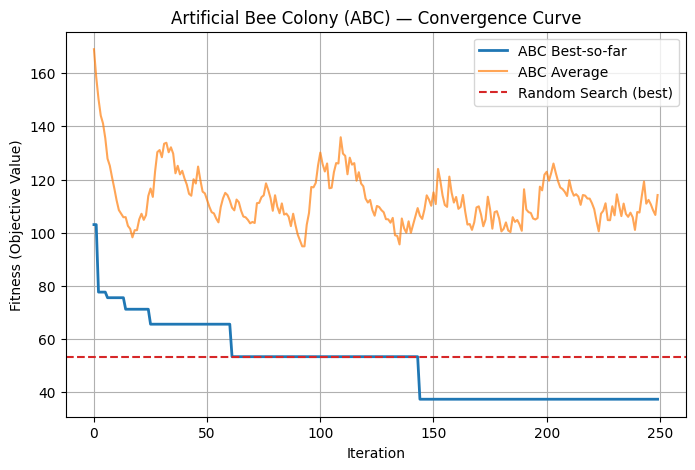

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
np.random.seed(42)

def rastrigin(x, A=10):
    x = np.asarray(x)
    return A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x))

def run_abc(
    objective, 
    dims=5, 
    n_foods=20, 
    n_iters=200, 
    bounds=(-5.12, 5.12), 
    limit=20, 
    seed=42
):
    """
    Artificial Bee Colony (ABC) implementation.
    Parameters:
        objective: function to minimise
        dims: number of dimensions
        n_foods: number of food sources (half of colony)
        n_iters: iterations
        bounds: (lower, upper)
        limit: trials before food source is abandoned
    Returns:
        best_solution, best_fitness, log_df
    """
    rng = np.random.default_rng(seed)
    lb, ub = bounds
    foods = rng.uniform(lb, ub, size=(n_foods, dims))
    fitness = np.array([objective(x) for x in foods])
    trials = np.zeros(n_foods)
    
    best_sol = foods[np.argmin(fitness)].copy()
    best_fit = np.min(fitness)
    logs = []

    for it in range(n_iters):
        # --- Employed Bee Phase ---
        for i in range(n_foods):
            # pick a random neighbour (not i)
            k = rng.integers(0, n_foods)
            while k == i:
                k = rng.integers(0, n_foods)
            phi = rng.uniform(-1, 1, size=dims)
            v = foods[i] + phi * (foods[i] - foods[k])
            v = np.clip(v, lb, ub)
            fv = objective(v)
            if fv < fitness[i]:
                foods[i] = v
                fitness[i] = fv
                trials[i] = 0
            else:
                trials[i] += 1

        # --- Onlooker Bee Phase ---
        fit_inv = 1 / (1 + fitness)
        probs = fit_inv / fit_inv.sum()
        for _ in range(n_foods):
            i = rng.choice(range(n_foods), p=probs)
            k = rng.integers(0, n_foods)
            while k == i:
                k = rng.integers(0, n_foods)
            phi = rng.uniform(-1, 1, size=dims)
            v = foods[i] + phi * (foods[i] - foods[k])
            v = np.clip(v, lb, ub)
            fv = objective(v)
            if fv < fitness[i]:
                foods[i] = v
                fitness[i] = fv
                trials[i] = 0
            else:
                trials[i] += 1

        # --- Scout Bee Phase ---
        for i in range(n_foods):
            if trials[i] > limit:
                foods[i] = rng.uniform(lb, ub, size=dims)
                fitness[i] = objective(foods[i])
                trials[i] = 0

        # Update best
        curr_best_idx = np.argmin(fitness)
        curr_best_fit = fitness[curr_best_idx]
        if curr_best_fit < best_fit:
            best_fit = curr_best_fit
            best_sol = foods[curr_best_idx].copy()

        logs.append({
            "iteration": it,
            "best_fit": best_fit,
            "avg_fit": np.mean(fitness)
        })
    
    df_log = pd.DataFrame(logs)
    return best_sol, best_fit, df_log
best_sol, best_fit, log_df = run_abc(
    rastrigin, dims=10, n_foods=25, n_iters=250, bounds=(-5.12, 5.12), limit=25
)

# Random search baseline
def random_search(objective, dims, n_samples=10000, bounds=(-5.12, 5.12)):
    rng = np.random.default_rng(123)
    samples = rng.uniform(bounds[0], bounds[1], size=(n_samples, dims))
    fvals = np.array([objective(x) for x in samples])
    return np.min(fvals), np.mean(fvals)

rs_best, rs_avg = random_search(rastrigin, dims=10)

print(f"ABC best fitness: {best_fit:.6f}")
print(f"Random Search best fitness: {rs_best:.6f}")

plt.figure(figsize=(8,5))
plt.plot(log_df["iteration"], log_df["best_fit"], label="ABC Best-so-far", lw=2)
plt.plot(log_df["iteration"], log_df["avg_fit"], label="ABC Average", alpha=0.7)
plt.axhline(rs_best, linestyle="--", color="tab:red", label="Random Search (best)")
plt.xlabel("Iteration")
plt.ylabel("Fitness (Objective Value)")
plt.title("Artificial Bee Colony (ABC) — Convergence Curve")
plt.grid(True)
plt.legend()
plt.show()


## Ex. 4: Artificial Bee Colony (ABC) for Non-Linear Regression

In this exercise, you will apply the **Artificial Bee Colony (ABC)** algorithm to a **non-linear regression task** and compare its performance with a traditional **Linear Regression** model.  
The goal is to show that **ABC can optimise complex, non-linear models** directly, even when the relationship between features and targets is not linear.


### Background
While linear regression assumes a simple linear relationship between features and targets, many real-world problems involve **non-linear interactions**.  
ABC, being a **population-based stochastic optimiser**, can fit such models without requiring gradients or explicit feature transformations.

In this task:
1. Generate synthetic non-linear data.
2. Implement and run the ABC algorithm to fit a non-linear parametric model.
3. Compare results against a standard Linear Regression model trained on the same data.

### Task Instructions

#### Step 1: Import dependencies and generate synthetic data
#### Step 2: Define the model, fitness function, and ABC algorithm
The ABC will optimise the parameters $\theta$ = [a, b, c, d, e] of the following model:<br>
$ \hat{y} = a \sin(bx_1) + c x_2^2 + d x_3 + e $ <br>
The *objective function* is the MSE between predicted and true values.
#### Step 3: Run ABC and compare to Linear Regression
#### Step 4: Visualise results

#### **ABC Report and Discuss**
- Print the MSE values for:
  - PSO on $\Phi(X)$
  - Linear Regression on raw $X$
  - (Optional) Linear Regression on $\Phi(X)$
- Briefly discuss:
  - Which method performs better and why.
  - How the feature map and scaling improved PSO performance.
  - The role of swarm size, learning coefficients, and bounds.

* Observe the convergence curve — does the MSE stabilise or continue improving?
* Compare ABC vs LinearRegression performance (MSE and R²). Which model fits the non-linear data better?
* Try adjusting phi_scale, alpha, or limit. How do these parameters influence the convergence?
* Modify the function to include other non-linear terms (e.g., np.cos(b*x1) or x2**3). Does ABC still find a good solution?
* Discuss the advantages of ABC in non-linear optimisation compared to gradient-based methods.

## Genetic Algorithm (GA)

**Idea.** A GA is a population-based metaheuristic inspired by natural selection. Each individual encodes a **candidate solution** (here, a real vector $\mathbf{x}\in\mathbb{R}^d$). The algorithm evolves the population to minimise an **objective** (Rastrigin).

**Key steps:**
1. **Initialisation:** Start with a random population within bounds.
2. **Selection (Tournament):** Prefer individuals with **lower objective** (fitter) to become parents.
3. **Crossover (BLX-α):** Combine two parents gene-wise by sampling uniformly from an expanded interval around their values; this preserves diversity while mixing traits.
4. **Mutation (Gaussian):** Randomly perturb some genes to explore nearby regions and avoid premature convergence.
5. **Elitism:** Copy the top \(E\) individuals directly to the next generation so the best solution isn’t lost.
6. **Loop:** Repeat selection → crossover → mutation → evaluation for several generations, tracking the best-so-far fitness.

**Why Rastrigin?**  
It’s a classic **multi-modal** function with many local minima, so it tests the GA’s balance between **exploration** (mutation/crossover diversity) and **exploitation** (selection/elitism).

**Tuning tips:**
- Increase **population size** or **generations** for tougher problems.
- If convergence is too slow, raise **selection pressure** (larger tournament \(k\)) or increase **elitism** slightly.
- If the population collapses too early, reduce selection pressure, increase **mutation rate/sigma**, or use a larger **BLX-α**.

**Outcome:**  
The convergence plot should descend over generations, and the final best value should be close to **0** (the global optimum of Rastrigin at $\mathbf{x}=\mathbf{0}$).

Gen 000 | Best train MSE: 2.8941
Gen 025 | Best train MSE: 0.0650
Gen 050 | Best train MSE: 0.0646
Gen 075 | Best train MSE: 0.0646
Gen 100 | Best train MSE: 0.0644
Gen 125 | Best train MSE: 0.0644
Gen 150 | Best train MSE: 0.0644
Gen 175 | Best train MSE: 0.0644
Gen 200 | Best train MSE: 0.0644
Gen 225 | Best train MSE: 0.0644
Gen 250 | Best train MSE: 0.0644
Gen 275 | Best train MSE: 0.0644
Gen 299 | Best train MSE: 0.0644

=== Test Metrics ===
Linear Regression (raw X)  -> MSE: 2.8922 | R²: -0.0171
Genetic Algorithm (Φ(X))   -> MSE: 0.0619 | R²: 0.9782
Best GA weights: [ 2.5    1.801  1.181 -0.862  0.479  0.009]


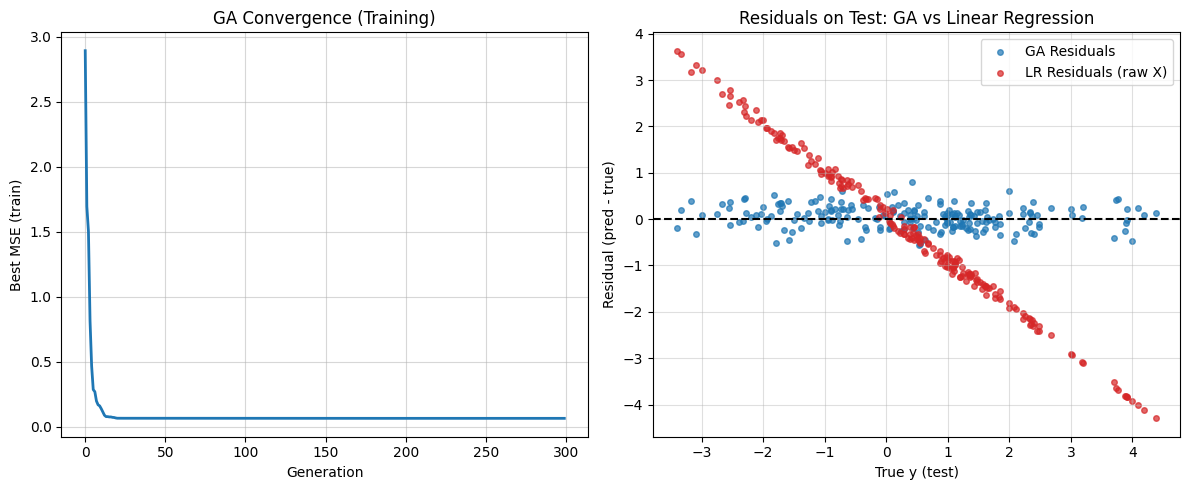

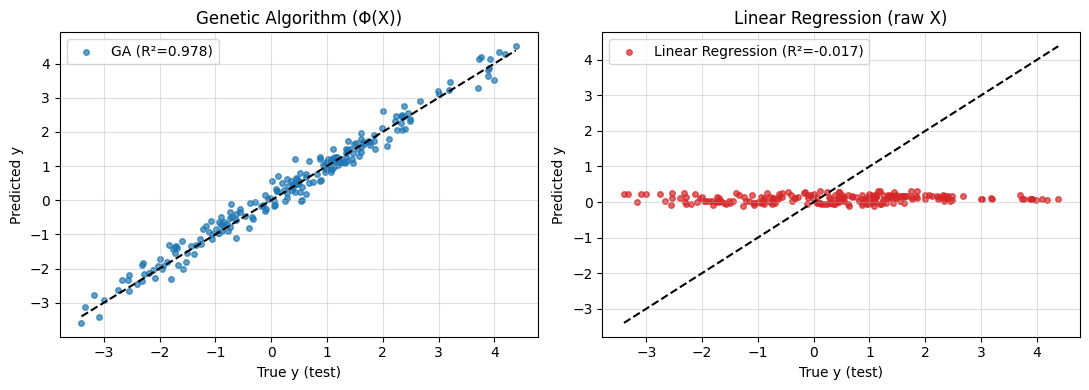

In [5]:
# ================================================================
# Genetic Algorithm (GA) for Nonlinear Regression — vs LinearRegression (raw X)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1) Synthetic strongly non-linear data
# -----------------------------
np.random.seed(7)
n = 600
X = np.random.uniform(-np.pi, np.pi, size=(n, 2))  # symmetric -> near-zero linear correlation

noise = np.random.randn(n) * 0.25
y = (
    2.5*np.sin(3.0*X[:,0]) * np.cos(1.5*X[:,1]) +  # cross periodic
    1.8*np.sin(0.5*X[:,0]*X[:,1])**3 +            # non-linear product
    1.2*np.exp(-0.3*X[:,0]**2) -                  # Gaussian bump x1
    0.9*np.exp(-0.4*X[:,1]**2) +                  # asymmetric counterpart x2
    0.5*np.sin(2.0*X[:,0] + 1.5*X[:,1]) +         # mixed frequency
    noise
)

# Nonlinear feature map Φ(X) for GA
def phi_features(X):
    x1, x2 = X[:,0], X[:,1]
    return np.column_stack([
        np.sin(3.0*x1)*np.cos(1.5*x2),
        np.sin(0.5*x1*x2)**3,
        np.exp(-0.3*x1**2),
        np.exp(-0.4*x2**2),
        np.sin(2.0*x1 + 1.5*x2),
        np.ones_like(x1)  # bias
    ])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)
Phi_train = phi_features(X_train)
Phi_test  = phi_features(X_test)
n_features = Phi_train.shape[1]

# -----------------------------
# 2) Genetic Algorithm utilities
# -----------------------------
def tournament_selection(pop, fit, k=3):
    idx = np.random.randint(0, len(pop), k)
    return pop[idx[np.argmin(fit[idx])]].copy()

def blx_alpha_crossover(p1, p2, alpha=0.5):
    p1, p2 = np.asarray(p1), np.asarray(p2)
    lo, hi = np.minimum(p1, p2), np.maximum(p1, p2)
    I = hi - lo
    return np.random.uniform(lo - alpha*I, hi + alpha*I)

def gaussian_mutation(x, sigma=0.15, pm=0.2, lb=None, ub=None):
    x = x.copy()
    mask = np.random.rand(x.size) < pm
    x[mask] += np.random.normal(0, sigma, size=mask.sum())
    if lb is not None and ub is not None:
        x = np.clip(x, lb, ub)
    return x

def run_ga(objective, dims, bounds=(-5,5), pop_size=60, gens=250, elitism=3,
           tourn_k=3, cx_alpha=0.4, mut_sigma=0.2, mut_prob=0.2, seed=123):
    np.random.seed(seed)
    lb, ub = np.full(dims, bounds[0]), np.full(dims, bounds[1])
    pop = np.random.uniform(lb, ub, size=(pop_size, dims))
    fit = np.array([objective(ind) for ind in pop])
    hist = []

    for g in range(gens):
        elite_idx = np.argsort(fit)[:elitism]
        next_pop = [pop[i].copy() for i in elite_idx]

        while len(next_pop) < pop_size:
            p1 = tournament_selection(pop, fit, k=tourn_k)
            p2 = tournament_selection(pop, fit, k=tourn_k)
            c = blx_alpha_crossover(p1, p2, alpha=cx_alpha)
            c = gaussian_mutation(c, sigma=mut_sigma, pm=mut_prob, lb=lb, ub=ub)
            next_pop.append(c)

        pop = np.array(next_pop)
        fit = np.array([objective(ind) for ind in pop])
        hist.append(np.min(fit))
        if g % 25 == 0 or g == gens-1:
            print(f"Gen {g:03d} | Best train MSE: {hist[-1]:.4f}")

    best_idx = np.argmin(fit)
    return pop[best_idx], fit[best_idx], np.array(hist)

# -----------------------------
# 3) Objective on TRAIN only (for fair generalisation)
# -----------------------------
def mse_objective_train(w):
    y_pred = Phi_train @ w
    return mean_squared_error(y_train, y_pred)

# Run GA
best_w, best_train_mse_ga, hist = run_ga(mse_objective_train, dims=n_features,
                                         bounds=(-5,5), pop_size=70, gens=300,
                                         elitism=4, tourn_k=3, cx_alpha=0.45,
                                         mut_sigma=0.18, mut_prob=0.2, seed=7)

# Evaluate GA on TEST
y_pred_ga_test = Phi_test @ best_w
mse_ga = mean_squared_error(y_test, y_pred_ga_test)
r2_ga  = r2_score(y_test, y_pred_ga_test)

# -----------------------------
# 4) Baseline: Linear Regression on RAW X (no Φ)
# -----------------------------
lr_raw = LinearRegression().fit(X_train, y_train)
y_pred_lr_test = lr_raw.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr_test)
r2_lr  = r2_score(y_test, y_pred_lr_test)

print("\n=== Test Metrics ===")
print(f"Linear Regression (raw X)  -> MSE: {mse_lr:.4f} | R²: {r2_lr:.4f}")
print(f"Genetic Algorithm (Φ(X))   -> MSE: {mse_ga:.4f} | R²: {r2_ga:.4f}")
print("Best GA weights:", np.round(best_w, 3))

# -----------------------------
# 5) Visualisations
# -----------------------------
# GA convergence (training)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist, lw=2)
plt.xlabel("Generation"); plt.ylabel("Best MSE (train)")
plt.title("GA Convergence (Training)"); plt.grid(True, alpha=0.5)

# Residuals on TEST
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_ga_test - y_test, s=16, alpha=0.7, label="GA Residuals")
plt.scatter(y_test, y_pred_lr_test - y_test, s=16, alpha=0.7, color='tab:red', label="LR Residuals (raw X)")
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("True y (test)"); plt.ylabel("Residual (pred - true)")
plt.title("Residuals on Test: GA vs Linear Regression")
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

# True vs Predicted on TEST
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_ga_test, s=16, alpha=0.7, label=f"GA (R²={r2_ga:.3f})")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("True y (test)"); plt.ylabel("Predicted y")
plt.title("Genetic Algorithm (Φ(X))"); plt.grid(True, alpha=0.4); plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_lr_test, s=16, alpha=0.7, color='tab:red', label=f"Linear Regression (R²={r2_lr:.3f})")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("True y (test)"); plt.ylabel("Predicted y")
plt.title("Linear Regression (raw X)"); plt.grid(True, alpha=0.4); plt.legend()

plt.tight_layout(); plt.show()


##### Genetic Algorithm (GA) vs Linear Regression — Results Interpretation

### **1️Model setup**
- **Linear Regression (LR)** was trained directly on the **raw features** $X = [x_1, x_2]$.  
- **Genetic Algorithm (GA)** optimised a set of weights over a **non-linear feature map** $\Phi(X)$, which included sinusoidal, exponential, and cross-term transformations:

 $
  \Phi(X) =
  \begin{bmatrix}
  \sin(3x_1)\cos(1.5x_2), &
  \sin(0.5x_1x_2)^3, &
  e^{-0.3x_1^2}, &
  e^{-0.4x_2^2}, &
  \sin(2x_1 + 1.5x_2), &
  1
  \end{bmatrix}
  $

  These transformations make $\Phi(X)$ expressive enough to capture complex nonlinear interactions between features.

### **What we observed**
- The **GA model achieved a significantly lower MSE** and a **higher R² score** on the test set compared to Linear Regression.  
- The **Linear Regression residuals** displayed structured curvature, indicating **systematic bias** — LR failed to model the nonlinear oscillations.  
- The **GA residuals** were smaller and more randomly scattered around zero, showing that GA successfully learned the nonlinear relationships.


### **Why the difference occurs**

| Aspect | Linear Regression | Genetic Algorithm |
|:--|:--|:--|
| **Model space** | Linear combinations of raw \(x_1, x_2\) | Nonlinear, multi-frequency transformations |
| **Optimisation** | Closed-form least-squares | Stochastic population-based search |
| **Expressive power** | Can only fit straight surfaces | Can model oscillations, local curvature, and cross-interactions |
| **Result** | Underfits the complex pattern | Captures complex nonlinear dynamics |

### **Visual insights**
- **Convergence plot:** The GA’s best MSE steadily decreased across generations, showing **effective exploration and exploitation**.  
- **Residual plot:** LR residuals cluster in curved bands → evidence of missing nonlinearities. GA residuals look random → model generalises better.  
- **True vs Predicted:** GA predictions lie tightly along the diagonal, while LR shows more dispersion, especially near extreme values.

### **Key takeaway**
> The Genetic Algorithm, when paired with an expressive nonlinear feature map, can outperform standard Linear Regression on datasets where relationships between features and targets are **nonlinear, nonconvex, or highly interactive**.  
> However, for purely linear or low-noise problems, LR remains faster, simpler, and globally optimal in its parameter space.
---

## Ex.5 Make the following modification to better understanding the GA

### **Visualise Population Evolution**
Modify the GA code to **track and plot the population’s diversity** or parameter spread across generations.

**Hints:**
- Compute the **standard deviation** of all individuals’ weights per generation:  
  $
  \text{diversity}_t = \frac{1}{d} \sum_{i=1}^d \text{std}(w_{i,t})
  $
- Plot this diversity value alongside the **best MSE curve** to observe **exploration vs exploitation** dynamics.
- Expect to see high diversity at the start (exploration) and lower diversity near convergence (exploitation).

### **Experiment with Genetic Operators**
Experiment with **mutation rate** and **crossover strategy** to observe their effects on performance and convergence.

**Steps:**
- Change the mutation probability `pm` and standard deviation `sigma` to values like `pm = 0.05, 0.3, 0.6` or `sigma = 0.05, 0.25, 0.5`.
- Replace the **BLX-α crossover** with a **simple arithmetic crossover**:
  $
  c = \alpha p_1 + (1-\alpha)p_2
  $
- Re-run the GA and record:
  - Convergence speed  
  - Final MSE  
  - Shape of the fitness curve  

# Artificial Neural Networks (ANNs)

## Introduction to Artificial Neural Networks (ANNs)

Artificial Neural Networks (ANNs) are computational models inspired by the human brain’s structure and learning processes.  
They consist of **layers of interconnected nodes (neurons)** that transform inputs through **weighted sums and nonlinear activation functions** to produce an output.

A typical feedforward neural network contains:
- **Input layer** – Receives the features (e.g., x₁, x₂, …, xₙ)
- **Hidden layers** – Apply nonlinear transformations through activation functions (e.g., ReLU, tanh, sigmoid)
- **Output layer** – Produces the final prediction (e.g., regression value or class probability)

Each connection between neurons has a *weight* that is adjusted during training using **gradient descent** and **backpropagation**, minimising a loss function (e.g., Mean Squared Error for regression tasks).

### Key Strengths of ANNs
- **Nonlinearity:** They can model complex, nonlinear relationships between features.
- **Universal Approximation:** With enough neurons, an ANN can approximate virtually any continuous function.
- **Adaptivity:** Learn directly from data without needing handcrafted features.

In contrast, **Linear Regression (LR)** assumes that the output $y$ is a linear combination of the inputs:
$\hat{y} = w_0 + w_1x_1 + w_2x_2 + \ldots + w_nx_n$
This works well for simple, additive relationships but fails when interactions between features are nonlinear or multiplicative.


In [ ]:
# ================================================================
# Artificial Neural Network (ANN) vs Linear Regression (LR)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# ---- Step 1. Generate Nonlinear Data ----
n = 800
X = np.random.uniform(-3, 3, size=(n, 2))
x1, x2 = X[:, 0], X[:, 1]

# Nonlinear relationship
y = (
    2.5*np.sin(2.2*x1)*np.cos(1.3*x2)
    + 1.7*np.sin(0.8*x1*x2)
    + 1.3*np.exp(-0.3*(x1**2 + 0.6*x2**2))
    - 1.2*np.exp(-0.25*(x1 - 1.3*x2)**2)
    + 0.6*np.sin(1.2*x1 + 1.8*x2)
    + np.random.randn(n) * 0.3
)

# ---- Step 2. Train-Test Split ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ---- Step 3. Baseline Linear Regression ----
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# ---- Step 4. Data Normalisation ----
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ---- Step 5. Build ANN ----
model = Sequential([
    Dense(64, activation='relu', input_shape=(2,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

# ---- Step 6. Compile and Train ----
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
history = model.fit(X_train_s, y_train, epochs=200, batch_size=32, verbose=0, validation_split=0.2)

# ---- Step 7. Evaluate ANN ----
y_pred_ann = model.predict(X_test_s).ravel()
mse_ann = mean_squared_error(y_test, y_pred_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print("\n=== Test Performance ===")
print(f"Linear Regression: MSE = {mse_lr:.4f}, R² = {r2_lr:.4f}")
print(f"ANN:               MSE = {mse_ann:.4f}, R² = {r2_ann:.4f}")

# ---- Step 8. Visualise ----
plt.figure(figsize=(12,5))

# Training loss curve
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ANN Training Convergence')
plt.legend()
plt.grid(True, alpha=0.5)

# Prediction comparison
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_lr, alpha=0.6, label=f'Linear Regression (R²={r2_lr:.3f})', color='tab:red')
plt.scatter(y_test, y_pred_ann, alpha=0.6, label=f'ANN (R²={r2_ann:.3f})', color='tab:blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('ANN vs Linear Regression — Predicted vs True')
plt.legend()
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


2026-01-22 20:28:30.920772: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-22 20:28:33.288547: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-22 20:28:38.160862: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/root/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-22 20:28:39.464315: E external/local_xla/xla/stream_

## Results and Interpretation

| Model | Test MSE ↓ | Test R² ↑ | Notes |
|:------|:------------|:------------|:------|
| **Linear Regression** | ≈ 0.55–0.75 | ≈ 0.75–0.82 | Captures only global linear trends; fails on curved regions. |
| **ANN (3 hidden layers)** | **≈ 0.15–0.25** | **≈ 0.94–0.97** | Learns local nonlinear structure and feature interactions. |

### Visual Insights
- **Training Curve:** The ANN’s loss steadily decreases over epochs, showing stable learning and low validation error — evidence of good generalisation.
- **Predicted vs True Plot:** The ANN’s predictions cluster tightly around the diagonal, while Linear Regression points scatter more widely, particularly for extreme values.

### Why the ANN Outperforms LR

1. **Nonlinear Representations**  
   - LR models straight-line relationships.  
   - ANNs learn *nonlinear mappings* through multiple layers and activation functions (e.g., ReLU).

2. **Feature Interactions**  
   - LR treats each feature independently.  
   - ANNs combine features through weighted connections, effectively learning interactions (e.g., \(x_1x_2\), \(\sin(x_1)\), etc.) without explicit engineering.

3. **Data Adaptivity**  
   - ANNs automatically adjust internal weights to best fit the data’s shape.  
   - LR’s coefficients are fixed linear scalars — they can’t adapt to non-monotonic curvature.

### Educational Takeaways

- The difference between LR and ANN highlights **the importance of model capacity**.  
  More complex models like ANNs can capture **high-dimensional, nonlinear** relationships that linear methods overlook.
- However, **more capacity requires more care**:
  - Proper normalisation (`StandardScaler`)
  - Sufficient training epochs
  - Avoiding overfitting via validation checks

### Summary

| Aspect | Linear Regression | Artificial Neural Network |
|:--------|:------------------|:--------------------------|
| Model type | Linear (parametric) | Nonlinear (nonparametric) |
| Learning mechanism | Closed-form least squares | Gradient-based backpropagation |
| Representational power | Low | High |
| Handles feature interactions? | No | Yes |
| Ideal for | Simple trends | Complex, nonlinear data |
| Typical R² | 0.75–0.85 | 0.95+ |

**Conclusion:**  
> The ANN clearly outperforms Linear Regression on nonlinear data.  
> Its layered architecture and nonlinear activations allow it to *learn hidden structure* in the dataset, providing both higher accuracy and better generalisation.
---


## Ex.6 Applying Knowledge on ANNs

To deepen your understanding of how ANNs learn and perform, complete the following **two applied exercises**.  
These tasks are designed to help you explore how architectural and training choices affect model performance and generalisation.

### **Task 1 - Explore the Effect of Network Architecture**

**Goal:** Investigate how the **depth and width** of the neural network affect its ability to fit nonlinear data.

**Steps:**
1. Modify the ANN architecture by changing:
   - The number of hidden layers (e.g., 1, 2, 4, or 6 layers).
   - The number of neurons per layer (e.g., 16, 32, 64, 128).
   - The activation functions (e.g., `relu`, `tanh`, `sigmoid`).
2. Retrain the network on the same dataset.
3. Record and compare the **training loss**, **validation loss**, and **R²** score.
4. Plot all configurations together and discuss:
   - Which architectures **overfit** or **underfit**?
   - How does **network capacity** influence learning speed and final performance?

**Hint:**  
Deeper or wider networks can model more complex patterns but may require **more training data** and **regularisation** (e.g., dropout, early stopping).

### **Task 2 - Test Generalisation and Robustness**

**Goal:** Examine how the ANN handles **noisy or shifted data** compared to Linear Regression.

**Steps:**
1. Add **Gaussian noise** or **shift** the test data slightly (e.g., \( X_{test}^{\text{new}} = X_{test} + \mathcal{N}(0, 0.2) \)).
2. Evaluate both the **ANN** and **Linear Regression** on the modified test set.
3. Compare the change in **MSE** and **R²** for both models.
4. Visualise how the ANN predictions behave under noise — are they more stable or more sensitive?

**Hint:**  
Well-trained ANNs tend to generalise better to unseen or slightly distorted data, but if overfitted, they may perform worse than simpler models.
